<a href="https://colab.research.google.com/github/ardianita/data-science-2026/blob/main/Pertemuan_4_Ardianita_Fauziyah_250401020128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1 (LOAD & INSPECT DATASET)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

In [2]:
# STEP 2 (STATISTIK DESKRIPTIF LENGKAP)

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Skewness : {col.skew():.3f}')


=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Skewness : 0.315

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Skewness : 0.319

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Skewness : -0.275

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Skewness : -0.103


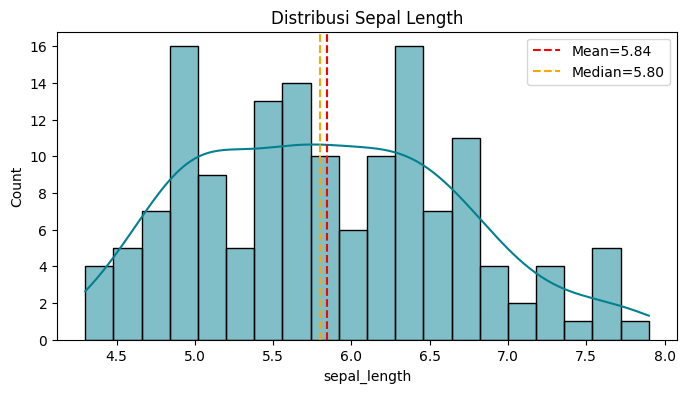

In [3]:
# STEP 3 (Histogram + KDE untuk sepal_length)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
             color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
           linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
           linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

Jenis distribusi dari histogram diatas adalah **Distribusi Normal**. Hal ini dikarenakan nilai mean dan median sama.

----- Boxplot Petal Length -----


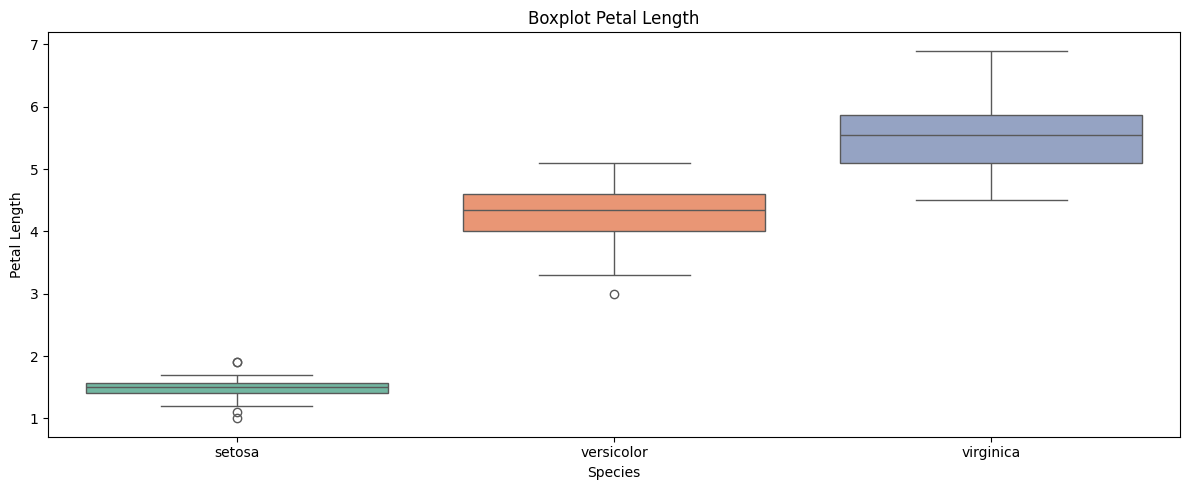


----- Identifikasi Spesies -----
Spesies dengan nilai terbesar		: virginica
Spesies dengan nilai terkecil		: setosa
Spesies dengan rata - rata terbesar	: virginica
Spesies dengan rata - rata terkecil	: setosa
Spesies yang paling tersebar			: virginica


In [19]:
# STEP 4 (Boxplot per Spesies)

# Membuat canvas dengan size (lebar 12 inci, tinggi 5 inci)
fig, axes = plt.subplots(figsize=(12, 5))

# Set boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False
);
plt.title('Boxplot Petal Length');
plt.xlabel('Species');
plt.ylabel('Petal Length');

print(f"----- Boxplot Petal Length -----")
plt.tight_layout();
plt.show();

# Identifikasi Spesies
spesies = df.groupby('species')['petal_length'].agg(
    mean='mean',
    min='min',
    max='max',
    std='std'
)

print(f"\n----- Identifikasi Spesies -----")
print(f"Spesies dengan nilai terbesar\t\t: {spesies['max'].idxmax()}")
print(f"Spesies dengan nilai terkecil\t\t: {spesies['min'].idxmin()}")
print(f"Spesies dengan rata - rata terbesar\t: {spesies['mean'].idxmax()}")
print(f"Spesies dengan rata - rata terkecil\t: {spesies['mean'].idxmin()}")
print(f"Spesies yang paling tersebar\t\t\t: {spesies['std'].idxmax()}")

In [23]:
# STEP 5 (Matriks Korelasi Pearson)

# Delete kolom yang type data nya bukan numerik
# Menghitung korelasi semua kolom numerik
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

# Korelasi tertinggi
max_pair = corr_masked.stack().idxmax()

# Korelasi terendah
min_pair = corr_masked.stack().idxmin()

print(f'\nKorelasi tertinggi\t: {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah\t: {min_pair} = {corr.loc[min_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi	: ('petal_width', 'petal_length') = 0.963
Korelasi terendah	: ('petal_length', 'sepal_width') = -0.428


Berdasarkan hasil perhitungan dari matrix Korelasi Pearson diatas diperoleh hasil sebagai berikut:


*   Korelasi Tertinggi terdapat pada pasangan kolom **Petal Width** dengan **Petal Length** dengan nilai korelasi sebesar **0.963** (Sangat Kuat). Semakin panjang mahkota bunga, biasanya semakin lebar juga mahkota bunganya.
*   Korelasi terendah terpadat pada pasangan **Petal Length** dan **Sepal Width** dengan nilai korelasi sebesar **-0.428** (Negatif Sedang). Semakin panjang mahkota bunga, lebar kelopak bungan cenderung kecil, begitupun sebaliknya.



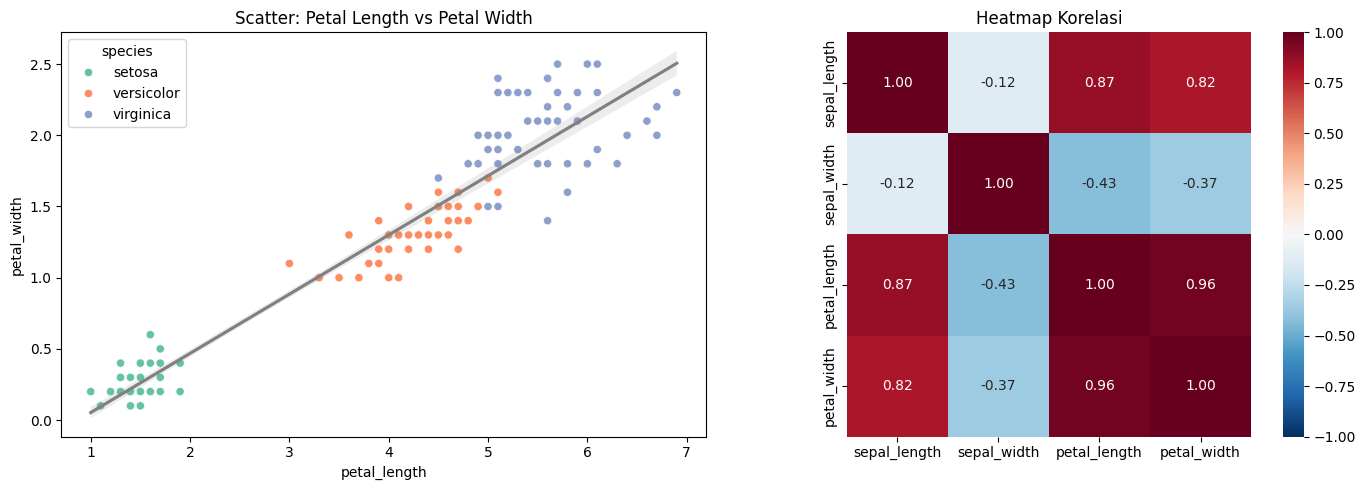

In [24]:
# STEP 6 (Scatter Plot & Heatmap)

# Membuat canvas dengan 1 baris 2 kolom dengan lebar 14 inch dan tinggi 5 inch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',      # memberi warna berbeda untuk setiap spesies
    palette='Set2',
    ax=axes[0]
)

# Regression Line
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Petal Length vs Petal Width')

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout();
plt.show()

Berdasarkan **Scatterplot** diatas diperoleh hasil bahwa korelasi **Petal Length** dengan **Petal Width** menunjukkan **Korelasi Positif**. Hal ini dikarenakan titik data menunjukkan pola naik ke kanan atas.

Berdasarkan **Heatmap** diatas diperoleh hasil sebagai berikut:
*   Korelasi Positif terdapat pada **Petal Length** dengan **Petal Width**, **Petal Length** dengan **Sepal Length**, dan **Petal Width** dengan **Sepal Length** yang ditunjukkan dengan warna merah
*   Korelasi Negatif terdapat pada **Sepal Width** dengan **Petal Width** dan **Petal Length** dengan **Sepal Width** yang ditunjukkan dengan warna biru
*   Korelasi Lemah terdapat pada **Sepal Length** dengan **Sepal Width** yang ditunjukkan dengan warna putih



